# ConvNeXt-Tiny Grad-CAM Localization Evaluation

This notebook evaluates Grad-CAM localization for the final ConvNeXt-Tiny model using the NIH ChestX-ray14 bounding-box subset.

- The heatmap threshold is tuned on `loc_tune` by **mean IoU**, then frozen
- Final localization is reported once on `loc_report`
- IoBB is reported next to IoU, predicted box size, and a centre-box control

## 1. Setup

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn

from torchvision import transforms
from torchvision.models import convnext_tiny
from PIL import Image

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
CUDA available: True
Device: cuda
GPU: Tesla T4


In [2]:
LABELS = [
    "Atelectasis",
    "Consolidation",
    "Infiltration",
    "Pneumothorax",
    "Edema",
    "Emphysema",
    "Fibrosis",
    "Effusion",
    "Pneumonia",
    "Pleural_Thickening",
    "Cardiomegaly",
    "Nodule",
    "Mass",
    "Hernia"
]

NUM_CLASSES = len(LABELS)

CHECKPOINT_PATH = (
    "/kaggle/input/notebooks/rabehalmutire/"
    "01-convnext-training/convnext_tiny_320_best.pth"
)

SPLITS_ROOT = (
    "/kaggle/input/datasets/iwmm10/"
    "chestxray-capstone-splits/capstone_splits/splits"
)

LOC_TUNE_PATH = os.path.join(SPLITS_ROOT, "loc_tune.csv")
LOC_REPORT_PATH = os.path.join(SPLITS_ROOT, "loc_report.csv")

BBOX_PATH = (
    "/kaggle/input/datasets/iwmm10/"
    "chestxray-capstone-splits/capstone_splits/BBox_List_2017.csv"
)

print("Number of model classes:", NUM_CLASSES)

Number of model classes: 14


## 2. Image Paths and Inference Preprocessing

In [3]:
NIH_DATA_ROOT = "/kaggle/input/datasets/nih-chest-xrays/data"

IMAGE_DIRS = [
    os.path.join(
        NIH_DATA_ROOT,
        f"images_{i:03d}",
        "images"
    )
    for i in range(1, 13)
]

image_path_map = {}

for directory in IMAGE_DIRS:
    for filename in os.listdir(directory):
        if filename.lower().endswith(".png"):
            image_path_map[filename] = os.path.join(directory, filename)

print("Total indexed images:", len(image_path_map))

Total indexed images: 112120


In [4]:
IMAGE_SIZE = 320
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("Inference transform ready:", IMAGE_SIZE, "x", IMAGE_SIZE)

Inference transform ready: 320 x 320


## 3. Localization Splits and Bounding Boxes

In [5]:
loc_tune_df = pd.read_csv(LOC_TUNE_PATH)
loc_report_df = pd.read_csv(LOC_REPORT_PATH)
bbox_df = pd.read_csv(BBOX_PATH)

# Match the annotation class name to the model label.
bbox_df["Finding Label"] = bbox_df["Finding Label"].replace({
    "Infiltrate": "Infiltration"
})

# Bounding boxes that belong to each localization split
tune_bbox_df = bbox_df[
    bbox_df["Image Index"].isin(set(loc_tune_df["Image Index"]))
].copy()

report_bbox_df = bbox_df[
    bbox_df["Image Index"].isin(set(loc_report_df["Image Index"]))
].copy()

print("loc_tune:", loc_tune_df.shape)
print("loc_report:", loc_report_df.shape)
print("Bounding-box annotations:", bbox_df.shape)
print("Annotated classes:", sorted(bbox_df["Finding Label"].unique()))
print("Boxes in loc_tune:", len(tune_bbox_df), "| Boxes in loc_report:", len(report_bbox_df))

loc_tune: (2606, 26)
loc_report: (2576, 26)
Bounding-box annotations: (984, 9)
Annotated classes: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax']
Boxes in loc_tune: 376 | Boxes in loc_report: 373


## 4. Load Final ConvNeXt-Tiny Model

In [6]:
# The checkpoint contains the final trained weights, so no separate
# ImageNet weight download is needed here.
model = convnext_tiny(weights=None)

in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Final trained model loaded successfully")
print("Classifier input features:", in_features)
print("Output classes:", NUM_CLASSES)

Final trained model loaded successfully
Classifier input features: 768
Output classes: 14


## 5. Grad-CAM Setup

In [7]:
# Final depthwise convolution in the last ConvNeXt block.
target_layer = model.features[-1][-1].block[0]

activations = {}
gradients = {}

def forward_hook(module, inputs, output):
    activations["value"] = output

def backward_hook(module, grad_input, grad_output):
    gradients["value"] = grad_output[0]

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

print("Grad-CAM target layer:", target_layer)
print("Grad-CAM hooks registered")

Grad-CAM target layer: Conv2d(768, 768, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=768)
Grad-CAM hooks registered


In [8]:
# Grad-CAM localization utilities

def generate_gradcam(image, target_class):
    input_tensor = eval_transform(image).unsqueeze(0).to(device)

    model.zero_grad()

    logits = model(input_tensor)
    score = logits[0, target_class]
    score.backward()

    acts = activations["value"]
    grads = gradients["value"]

    weights = grads.mean(dim=(2, 3), keepdim=True)

    cam = (weights * acts).sum(dim=1)
    cam = torch.relu(cam)

    cam = cam[0]
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    return cam.detach().cpu().numpy()


def heatmap_to_bbox(gradcam_map, image_size, threshold):
    cam_img = Image.fromarray(np.uint8(gradcam_map * 255))
    cam_img = cam_img.resize(image_size)

    cam_resized = np.array(cam_img) / 255.0

    binary_mask = cam_resized >= threshold

    ys, xs = np.where(binary_mask)

    if len(xs) == 0 or len(ys) == 0:
        return None

    x = xs.min()
    y = ys.min()
    w = xs.max() - xs.min() + 1
    h = ys.max() - ys.min() + 1

    return (x, y, w, h)


def calculate_iobb(pred_bbox, gt_bbox):
    if pred_bbox is None:
        return 0.0

    pred_x, pred_y, pred_w, pred_h = pred_bbox
    gt_x, gt_y, gt_w, gt_h = gt_bbox

    pred_x2 = pred_x + pred_w
    pred_y2 = pred_y + pred_h

    gt_x2 = gt_x + gt_w
    gt_y2 = gt_y + gt_h

    inter_x1 = max(pred_x, gt_x)
    inter_y1 = max(pred_y, gt_y)
    inter_x2 = min(pred_x2, gt_x2)
    inter_y2 = min(pred_y2, gt_y2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)

    intersection_area = inter_w * inter_h
    pred_area = pred_w * pred_h

    return intersection_area / pred_area if pred_area > 0 else 0.0



def calculate_iou(pred_bbox, gt_bbox):
    if pred_bbox is None:
        return 0.0

    px, py, pw, ph = pred_bbox
    gx, gy, gw, gh = gt_bbox

    inter_w = max(0, min(px + pw, gx + gw) - max(px, gx))
    inter_h = max(0, min(py + ph, gy + gh) - max(py, gy))

    intersection_area = inter_w * inter_h
    union_area = pw * ph + gw * gh - intersection_area

    return intersection_area / union_area if union_area > 0 else 0.0


def centre_box(pred_bbox, image_size):
    # Control: same size as the Grad-CAM box, placed at the image centre.
    # It ignores the heatmap completely.
    if pred_bbox is None:
        return None

    W, H = image_size
    _, _, w, h = pred_bbox

    return ((W - w) / 2, (H - h) / 2, w, h)


print("Localization functions ready")

Localization functions ready


## 6. Grad-CAM Sanity Check

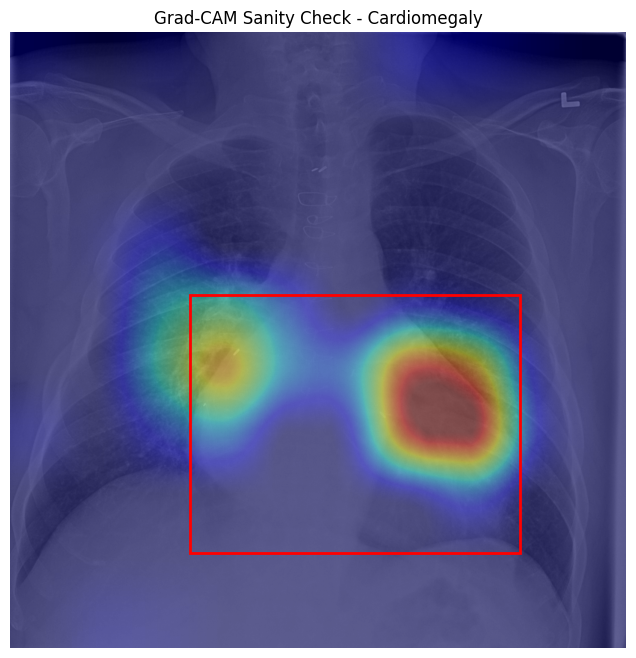

In [9]:
# Use one annotated Cardiomegaly case from loc_tune to verify alignment.
loc_tune_with_bbox = loc_tune_df[
    loc_tune_df["Image Index"].isin(bbox_df["Image Index"])
]

cardio_bbox_images = loc_tune_with_bbox[
    loc_tune_with_bbox["Image Index"].isin(
        bbox_df.loc[
            bbox_df["Finding Label"] == "Cardiomegaly",
            "Image Index"
        ]
    )
]

sample_row = cardio_bbox_images.iloc[0]
image_name = sample_row["Image Index"]

image = Image.open(image_path_map[image_name]).convert("RGB")

target_class = LABELS.index("Cardiomegaly")
gradcam_map = generate_gradcam(image, target_class)

sample_bbox = bbox_df[
    (bbox_df["Image Index"] == image_name) &
    (bbox_df["Finding Label"] == "Cardiomegaly")
]

cam_img = Image.fromarray(np.uint8(gradcam_map * 255))
cam_img = cam_img.resize(image.size)
cam_resized = np.array(cam_img) / 255.0

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(np.array(image), cmap="gray")
ax.imshow(cam_resized, cmap="jet", alpha=0.4)

for _, gt in sample_bbox.iterrows():
    rect = patches.Rectangle(
        (gt["Bbox [x"], gt["y"]),
        gt["w"],
        gt["h]"],
        linewidth=2,
        edgecolor="red",
        facecolor="none",
        label="Ground Truth"
    )
    ax.add_patch(rect)

ax.set_title("Grad-CAM Sanity Check - Cardiomegaly")
ax.axis("off")
plt.show()

The sanity check shows that the Grad-CAM heatmap is aligned with the X-ray

## 7. Grad-CAM for Every Annotated Pair

Grad-CAM does not depend on the heatmap threshold, so each image-class pair is computed **once** and reused for every threshold.

If an image has several boxes for the same class, the best overlap is used.

In [10]:
def collect_cams(split_bbox_df):
    records = []

    pairs = split_bbox_df[["Image Index", "Finding Label"]].drop_duplicates()

    for i, (_, row) in enumerate(pairs.iterrows(), start=1):
        image_name = row["Image Index"]
        finding = row["Finding Label"]

        if finding not in LABELS or image_name not in image_path_map:
            continue

        image = Image.open(image_path_map[image_name]).convert("RGB")
        cam = generate_gradcam(image, LABELS.index(finding))

        gt_rows = split_bbox_df[
            (split_bbox_df["Image Index"] == image_name) &
            (split_bbox_df["Finding Label"] == finding)
        ]

        gt_boxes = [
            (r["Bbox [x"], r["y"], r["w"], r["h]"])
            for _, r in gt_rows.iterrows()
        ]

        records.append({
            "Image": image_name,
            "Class": finding,
            "cam": cam,
            "size": image.size,
            "gt": gt_boxes
        })

        if i % 50 == 0:
            print(f"Processed {i}/{len(pairs)} image-class pairs")

    return records


def score(records, threshold):
    rows = []

    for r in records:
        pred_bbox = heatmap_to_bbox(r["cam"], r["size"], threshold)
        ctrl_bbox = centre_box(pred_bbox, r["size"])
        W, H = r["size"]

        rows.append({
            "Image": r["Image"],
            "Class": r["Class"],
            "IoBB": max(calculate_iobb(pred_bbox, g) for g in r["gt"]),
            "IoU": max(calculate_iou(pred_bbox, g) for g in r["gt"]),
            "Box_area": 0.0 if pred_bbox is None else (pred_bbox[2] * pred_bbox[3]) / (W * H),
            "Centre_IoBB": max(calculate_iobb(ctrl_bbox, g) for g in r["gt"])
        })

    return pd.DataFrame(rows)


def summarize(df):
    return {
        "Mean_IoBB": df["IoBB"].mean(),
        "Mean_IoU": df["IoU"].mean(),
        "Box_area": df["Box_area"].mean(),
        "IoBB_0.1": (df["IoBB"] >= 0.1).mean(),
        "IoBB_0.25": (df["IoBB"] >= 0.25).mean(),
        "IoBB_0.5": (df["IoBB"] >= 0.5).mean(),
        "Centre_0.25": (df["Centre_IoBB"] >= 0.25).mean()
    }


print("Evaluation helpers ready")

Evaluation helpers ready


## 8. Tune Heatmap Threshold on `loc_tune`

The threshold is chosen by **mean IoU**, not mean IoBB.

IoBB divides by the predicted box area, so a smaller box can only help it. Raising the threshold shrinks the box, which makes "maximize IoBB" favour the highest threshold tried. IoU divides by the union of both boxes, so it penalizes boxes that are too small **and** too large.

In [11]:
tune_records = collect_cams(tune_bbox_df)
print("loc_tune image-class pairs:", len(tune_records))

thresholds = [round(t, 2) for t in np.arange(0.05, 0.96, 0.05)]

tune_sweep = pd.DataFrame([
    {"T": t, **summarize(score(tune_records, t))}
    for t in thresholds
])

display(tune_sweep.round(4))

Processed 50/376 image-class pairs
Processed 100/376 image-class pairs
Processed 150/376 image-class pairs
Processed 200/376 image-class pairs
Processed 250/376 image-class pairs
Processed 300/376 image-class pairs
Processed 350/376 image-class pairs
loc_tune image-class pairs: 376


,T,Mean_IoBB,Mean_IoU,Box_area,IoBB_0.1,IoBB_0.25,IoBB_0.5,Centre_0.25
0,0.05,0.0926,0.0920,0.9226,0.3191,0.0771,0.0106,0.0798
1,0.10,0.1054,0.1035,0.8439,0.3298,0.1090,0.0266,0.1144
2,0.15,0.1256,0.1186,0.7594,0.3590,0.1436,0.0426,0.1543
3,0.20,0.1457,0.1334,0.6832,0.3856,0.1729,0.0745,0.1755
4,0.25,0.1697,0.1458,0.6011,0.4229,0.2128,0.0984,0.2101
5,0.30,0.1945,0.1582,0.5250,0.4574,0.2553,0.1277,0.2473
6,0.35,0.2217,0.1677,0.4580,0.4814,0.2979,0.1569,0.2633
7,0.40,0.2400,0.1752,0.4036,0.5186,0.3271,0.1782,0.2739
8,0.45,0.2628,0.1806,0.3392,0.5346,0.3590,0.2021,0.2872
9,0.50,0.2917,0.1826,0.2814,0.5532,0.3670,0.2606,0.2899


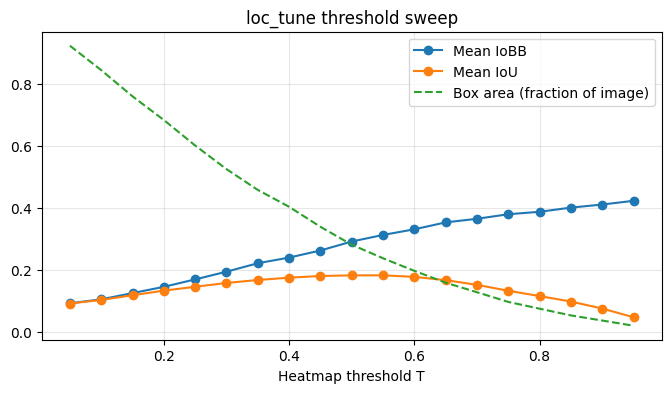

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tune_sweep["T"], tune_sweep["Mean_IoBB"], marker="o", label="Mean IoBB")
ax.plot(tune_sweep["T"], tune_sweep["Mean_IoU"], marker="o", label="Mean IoU")
ax.plot(tune_sweep["T"], tune_sweep["Box_area"], linestyle="--", label="Box area (fraction of image)")
ax.set_xlabel("Heatmap threshold T")
ax.set_title("loc_tune threshold sweep")
ax.legend()
ax.grid(alpha=0.3)
plt.savefig("gradcam_tune_sweep.png", bbox_inches="tight", dpi=100)
plt.show()

In [13]:
# Frozen here, before loc_report is touched.
FINAL_HEATMAP_THRESHOLD = float(
    tune_sweep.loc[tune_sweep["Mean_IoU"].idxmax(), "T"]
)

print("Selected threshold (max mean IoU on loc_tune):", FINAL_HEATMAP_THRESHOLD)

Selected threshold (max mean IoU on loc_tune): 0.55


Mean IoBB keeps rising all the way to the highest threshold while the box shrinks, and mean IoU peaks in the middle. That is why IoU is used for selection.

## 9. Final Localization Evaluation on `loc_report`

In [14]:
report_records = collect_cams(report_bbox_df)
report_results_df = score(report_records, FINAL_HEATMAP_THRESHOLD)

print("loc_report image-class pairs:", len(report_results_df))

final_summary = pd.DataFrame([{
    "T": FINAL_HEATMAP_THRESHOLD,
    **summarize(report_results_df)
}])

display(final_summary.round(4))

Processed 50/373 image-class pairs
Processed 100/373 image-class pairs
Processed 150/373 image-class pairs
Processed 200/373 image-class pairs
Processed 250/373 image-class pairs
Processed 300/373 image-class pairs
Processed 350/373 image-class pairs
loc_report image-class pairs: 373


,T,Mean_IoBB,Mean_IoU,Box_area,IoBB_0.1,IoBB_0.25,IoBB_0.5,Centre_0.25
0,0.55,0.3264,0.179,0.2359,0.6113,0.4209,0.2761,0.3217


In [15]:
# Reference only: the threshold that maximizes mean IoBB on loc_tune.
# Higher IoBB here comes with much smaller boxes and lower IoU.
T_IOBB = float(tune_sweep.loc[tune_sweep["Mean_IoBB"].idxmax(), "T"])

reference = pd.DataFrame([
    {"Selection": "Max IoU (used)", "T": FINAL_HEATMAP_THRESHOLD, **summarize(report_results_df)},
    {"Selection": "Max IoBB (reference)", "T": T_IOBB, **summarize(score(report_records, T_IOBB))}
])

display(reference.round(4))

,Selection,T,Mean_IoBB,Mean_IoU,Box_area,IoBB_0.1,IoBB_0.25,IoBB_0.5,Centre_0.25
0,Max IoU (used),0.55,0.3264,0.1790,0.2359,0.6113,0.4209,0.2761,0.3217
1,Max IoBB (reference),0.95,0.4274,0.0483,0.0247,0.5469,0.4853,0.4182,0.3137


## 10. Class-wise Localization Results

`Centre_0.25` is a control: the same-sized box placed at the image centre, ignoring the heatmap. A class only shows real localization if Grad-CAM beats this control.

In [16]:
class_summary = pd.DataFrame([
    {"Class": cls, "Images": len(sub), **summarize(sub)}
    for cls, sub in report_results_df.groupby("Class")
]).sort_values("Mean_IoU", ascending=False)

class_summary["Gain_over_centre"] = class_summary["IoBB_0.25"] - class_summary["Centre_0.25"]

display(class_summary.round(4))

,Class,Images,Mean_IoBB,Mean_IoU,Box_area,IoBB_0.1,IoBB_0.25,IoBB_0.5,Centre_0.25,Gain_over_centre
1,Cardiomegaly,81,0.7598,0.3015,0.1388,0.9877,0.9259,0.8148,0.9630,-0.0370
6,Pneumonia,53,0.3141,0.2072,0.3213,0.6981,0.4151,0.2264,0.2642,0.1509
2,Effusion,44,0.2575,0.1890,0.2887,0.6591,0.3409,0.1818,0.1136,0.2273
4,Mass,30,0.2202,0.1534,0.2037,0.4000,0.3333,0.1333,0.1667,0.1667
0,Atelectasis,57,0.1869,0.1502,0.1800,0.5263,0.2807,0.0877,0.0526,0.2281
3,Infiltration,41,0.2553,0.1455,0.3003,0.5366,0.3171,0.1951,0.2683,0.0488
7,Pneumothorax,33,0.0749,0.0607,0.3503,0.2727,0.1212,0.0000,0.1212,0.0000
5,Nodule,34,0.0596,0.0565,0.1991,0.2647,0.0588,0.0000,0.0000,0.0588


- **Cardiomegaly** has the highest IoBB, but the centre control scores about the same. The heart sits in the middle of almost every chest X-ray, so this result reflects anatomy more than explanation quality
- **Effusion, Atelectasis, Mass, and Pneumonia** clearly beat the centre control, so Grad-CAM is pointing at the right region for these classes
- **Infiltration** is only slightly above the control
- **Pneumothorax** is no better than the control, and **Nodule** is almost never localized. Nodules are small and the Grad-CAM map is a coarse 10×10 grid

## 11. Representative Grad-CAM Examples

For each class, the example closest to that class's mean IoBB is shown, so the examples are typical rather than hand-picked.

Red = radiologist box, blue = Grad-CAM box.

In [17]:
example_classes = ["Cardiomegaly", "Effusion", "Nodule"]

representative_examples = []

for class_name in example_classes:
    class_rows = report_results_df[report_results_df["Class"] == class_name].copy()
    class_rows["Distance_to_Mean"] = (class_rows["IoBB"] - class_rows["IoBB"].mean()).abs()
    representative_examples.append(class_rows.sort_values("Distance_to_Mean").iloc[0])

representative_examples_df = pd.DataFrame(representative_examples)

display(representative_examples_df.round(4))

,Image,Class,IoBB,IoU,Box_area,Centre_IoBB,Distance_to_Mean
90,00004344_022.png,Cardiomegaly,0.7585,0.4531,0.1163,0.4230,0.0013
169,00028509_007.png,Effusion,0.2632,0.1863,0.1654,0.1132,0.0057
264,00019013_002.png,Nodule,0.0575,0.0563,0.0269,0.0000,0.0022


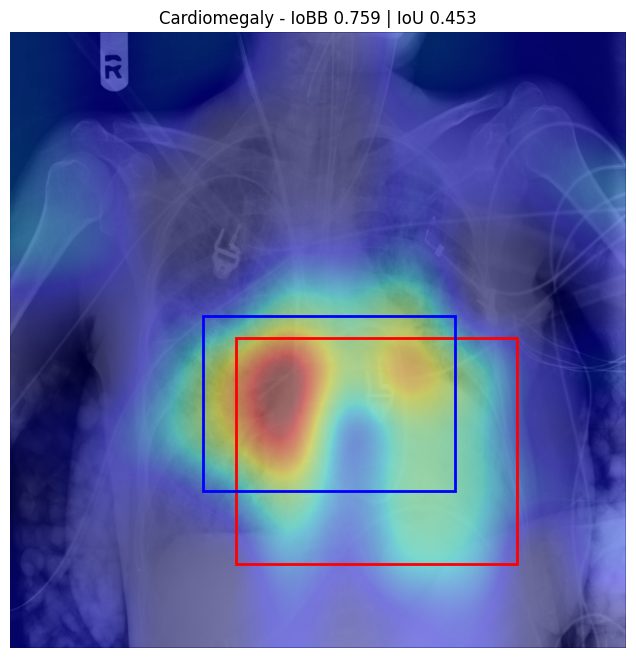

saved gradcam_cardiomegaly_00004344_022.png


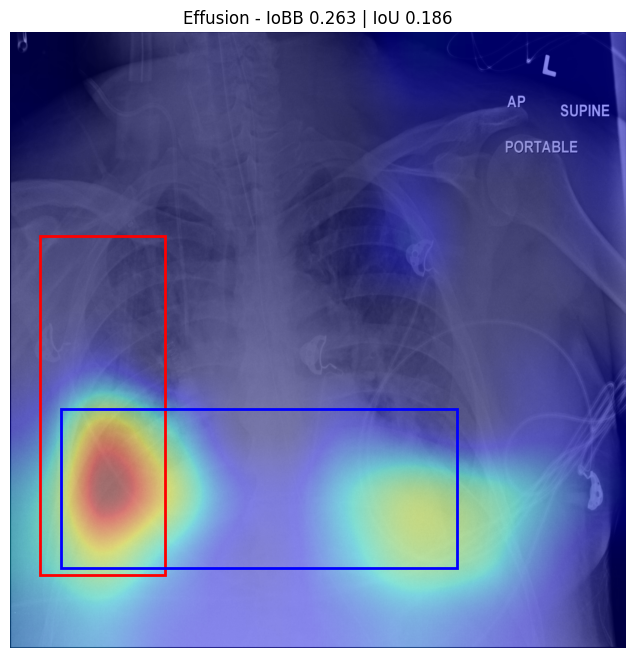

saved gradcam_effusion_00028509_007.png


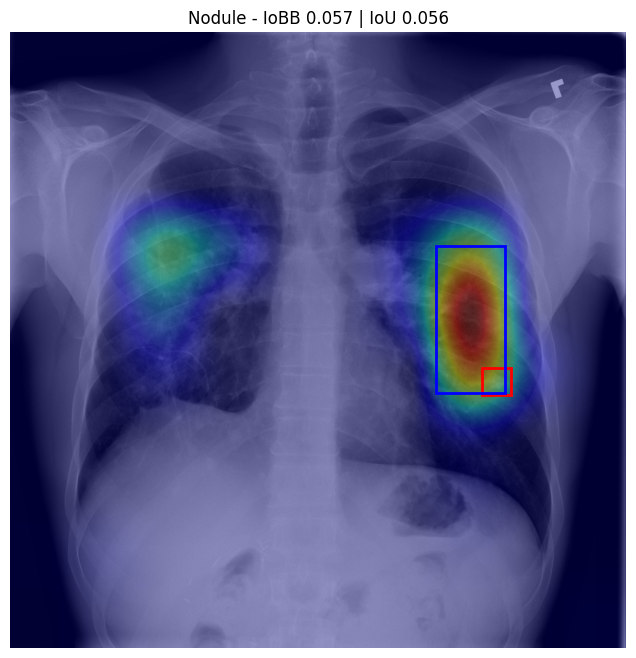

saved gradcam_nodule_00019013_002.png


In [18]:
record_lookup = {(r["Image"], r["Class"]): r for r in report_records}

for _, row in representative_examples_df.iterrows():
    image_name = row["Image"]
    class_name = row["Class"]
    rec = record_lookup[(image_name, class_name)]

    image = Image.open(image_path_map[image_name]).convert("RGB")
    pred_bbox = heatmap_to_bbox(rec["cam"], rec["size"], FINAL_HEATMAP_THRESHOLD)

    cam_resized = np.array(
        Image.fromarray(np.uint8(rec["cam"] * 255)).resize(image.size)
    ) / 255.0

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(np.array(image), cmap="gray")
    ax.imshow(cam_resized, cmap="jet", alpha=0.4)

    for g in rec["gt"]:
        ax.add_patch(patches.Rectangle(
            (g[0], g[1]), g[2], g[3],
            linewidth=2, edgecolor="red", facecolor="none"
        ))

    if pred_bbox is not None:
        ax.add_patch(patches.Rectangle(
            (pred_bbox[0], pred_bbox[1]), pred_bbox[2], pred_bbox[3],
            linewidth=2, edgecolor="blue", facecolor="none"
        ))

    ax.set_title(f"{class_name} - IoBB {row['IoBB']:.3f} | IoU {row['IoU']:.3f}")
    ax.axis("off")

    out_path = f"gradcam_{class_name.lower()}_{image_name}"
    plt.savefig(out_path, bbox_inches="tight", dpi=100)
    plt.show()
    print("saved", out_path)

## 12. Save Results

In [19]:
tune_sweep.to_csv("gradcam_tune_sweep.csv", index=False)
final_summary.to_csv("gradcam_overall_results.csv", index=False)
class_summary.to_csv("gradcam_iobb_results.csv", index=False)
report_results_df.to_csv("gradcam_report_per_image.csv", index=False)
representative_examples_df.to_csv("gradcam_representative_examples.csv", index=False)

print("Saved results to /kaggle/working")

Saved results to /kaggle/working


## 13. Summary

- Final model: ConvNeXt-Tiny 320×320 BCE checkpoint, loaded read-only
- Grad-CAM target layer: `model.features[-1][-1].block[0]`, from the raw class logit
- IoBB = intersection / predicted box area, as defined for ChestX-ray14 (Wang et al., 2017)
- Heatmap threshold chosen on `loc_tune` by **mean IoU**, then frozen before `loc_report`
- All 8 annotated classes are evaluated, including Infiltration (`Infiltrate` in the annotation file)
- IoBB is always reported next to IoU, box size, and a centre-box control

Main finding: localization quality is strongly class-dependent. Effusion, Atelectasis, Mass, and Pneumonia clearly beat the centre control, Cardiomegaly is explained mostly by anatomy, Pneumothorax is no better than chance placement, and Nodule is almost never localized.

The Grad-CAM results are intended for research and educational explainability and should not be interpreted as clinically validated lesion localization.